In [99]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

from skimage.io import imread, imshow
from skimage.color import rgb2hsv, rgb2gray
from skimage.exposure import histogram, cumulative_distribution
from skimage.filters import threshold_otsu

/tmp/ipython-input-3677688132.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail)


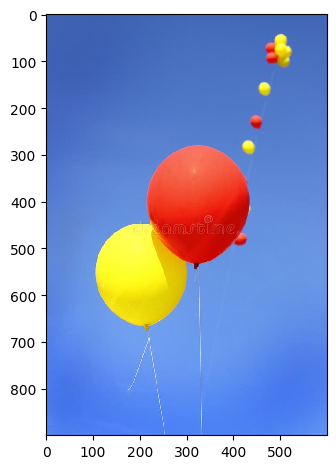

In [100]:
url = "https://thumbs.dreamstime.com/b/yellow-red-balloons-10992473.jpg"
sail = imread(url)
imshow(sail)

/tmp/ipython-input-1458516483.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail_gray)


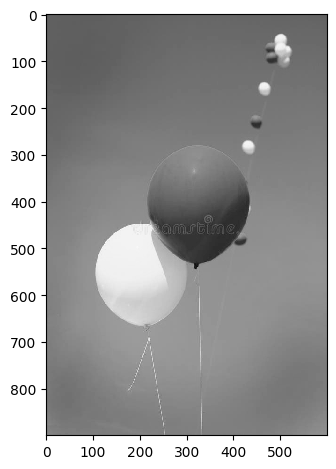

In [101]:
sail_gray = rgb2gray(sail)
imshow(sail_gray)

/tmp/ipython-input-2486807208.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail_gray_bw)


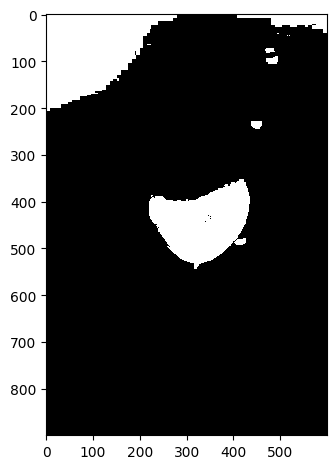

In [102]:
th = 0.4
sail_gray_bw = sail_gray<th
imshow(sail_gray_bw)

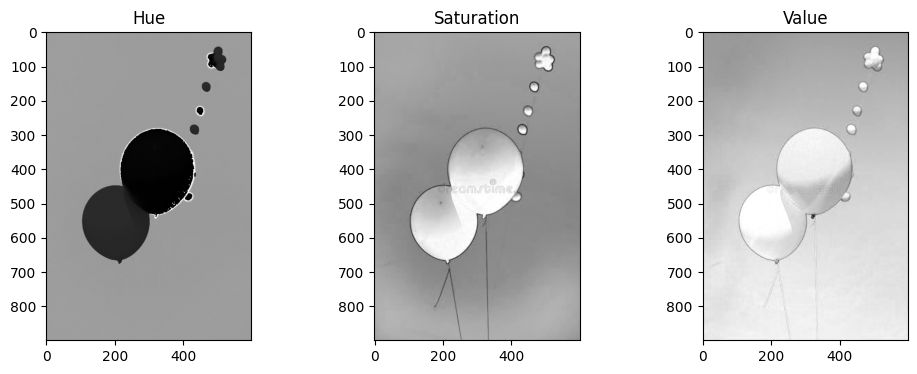

In [103]:
sail_hsv = rgb2hsv(sail)

fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(sail_hsv[:,:,0], cmap='gray')
ax[0].set_title('Hue')
ax[1].imshow(sail_hsv[:,:,1], cmap='gray')
ax[1].set_title('Saturation')
ax[2].imshow(sail_hsv[:,:,2], cmap='gray')
ax[2].set_title('Value');

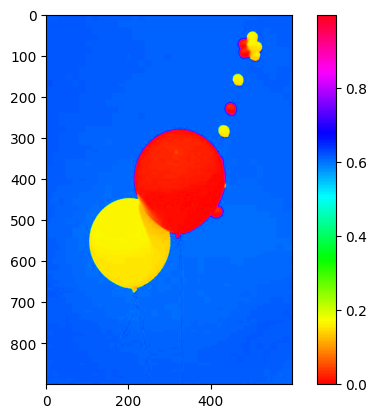

In [104]:
plt.imshow(sail_hsv[:,:,0],cmap='hsv')
plt.colorbar()

/tmp/ipython-input-563005546.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail_masked)


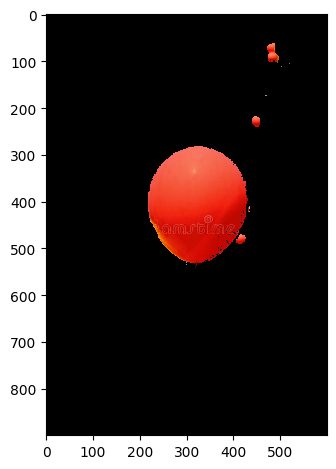

In [105]:
lower_mask = sail_hsv[:,:,0] > 0
upper_mask = sail_hsv[:,:,0] < 0.1
mask = upper_mask*lower_mask
plt.imshow(mask)
red = sail[:,:,0]*mask
green = sail[:,:,1]*mask
blue = sail[:,:,2]*mask
sail_masked = np.dstack((red,green,blue))
imshow(sail_masked)

/tmp/ipython-input-1520554061.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail_masked)


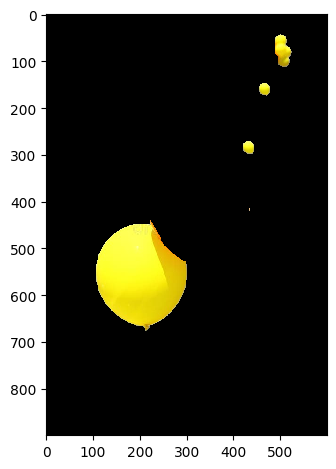

In [106]:
lower_mask = sail_hsv[:,:,0] > 0.08
upper_mask = sail_hsv[:,:,0] < 0.19
mask = upper_mask*lower_mask
plt.imshow(mask)

red = sail[:,:,0]*mask
green = sail[:,:,1]*mask
blue = sail[:,:,2]*mask
sail_masked = np.dstack((red,green,blue))
imshow(sail_masked)

/tmp/ipython-input-1767428501.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sail_masked)


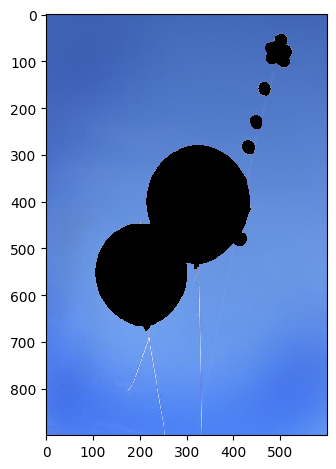

In [107]:
lower_mask = sail_hsv[:,:,0] > 0.5
upper_mask = sail_hsv[:,:,0] < 0.75
mask = upper_mask*lower_mask
plt.imshow(mask)

red = sail[:,:,0]*mask
green = sail[:,:,1]*mask
blue = sail[:,:,2]*mask
sail_masked = np.dstack((red,green,blue))
imshow(sail_masked)

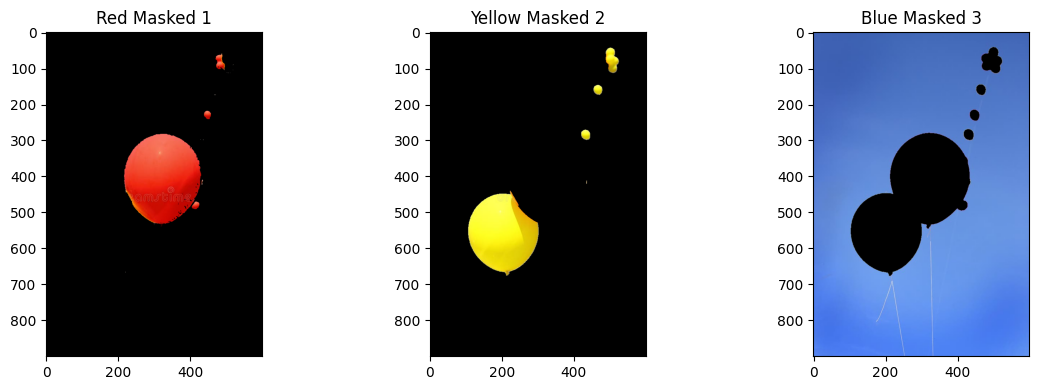

In [108]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# First subplot
lower_mask = sail_hsv[:,:,0] > 0
upper_mask = sail_hsv[:,:,0] < 0.1
mask = upper_mask * lower_mask
axes[0].imshow(mask)
axes[0].set_title("Mask 1")

red = sail[:,:,0] * mask
green = sail[:,:,1] * mask
blue = sail[:,:,2] * mask
sail_masked = np.dstack((red, green, blue))
axes[0].imshow(sail_masked)
axes[0].set_title("Red Masked 1")

# Second subplot
lower_mask = sail_hsv[:,:,0] > 0.08
upper_mask = sail_hsv[:,:,0] < 0.19
mask = upper_mask * lower_mask
axes[1].imshow(mask)
axes[1].set_title("Mask 2")

red = sail[:,:,0] * mask
green = sail[:,:,1] * mask
blue = sail[:,:,2] * mask
sail_masked = np.dstack((red, green, blue))
axes[1].imshow(sail_masked)
axes[1].set_title("Yellow Masked 2")

# Third subplot
lower_mask = sail_hsv[:,:,0] > 0.5
upper_mask = sail_hsv[:,:,0] < 0.75
mask = upper_mask * lower_mask
axes[2].imshow(mask)
axes[2].set_title("Mask 3")

red = sail[:,:,0] * mask
green = sail[:,:,1] * mask
blue = sail[:,:,2] * mask
sail_masked = np.dstack((red, green, blue))
axes[2].imshow(sail_masked)
axes[2].set_title("Blue Masked 3")

# Adjust spacing and display the plot
plt.tight_layout()
plt.show()

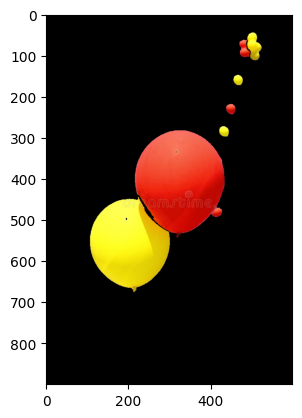

In [109]:
# Convert to HSV (if not already done)
hsv_image = rgb2hsv(sail)

# Extract channels
hue = hsv_image[:, :, 0]
sat = hsv_image[:, :, 1]
val = hsv_image[:, :, 2]

# Example mask for red balloons (hue near 0/1, high saturation and value)
mask_red = ((hue < 0.05) | (hue > 0.95)) & (sat > 0.5) & (val > 0.3)

# Example mask for yellow balloons (hue around 0.166, high saturation and value)
mask_yellow = (hue > 0.1) & (hue < 0.2) & (sat > 0.5) & (val > 0.3)

# Combine the masks
combined_mask = np.logical_or(mask_red, mask_yellow)

# Mask the image to show only balloons (background set to black)
masked_image = sail.copy()
masked_image[~combined_mask] = 0
plt.imshow(masked_image)